In [1]:
from utils import *

In [2]:
geom = "H 0 0 0; H 0 0 0.96"
basis = "sto-3g"

In [3]:
mol = gto.M(atom=geom, basis=basis, unit="Angstrom")
mf = scf.RHF(mol).run(verbose=0)
E_HF, E_FCI = mf.e_tot, fci.FCI(mf).kernel()[0]
print(f"Hartree-Fock energy: {E_HF:.6f} Ha")
print(f"Full CI energy: {E_FCI:.6f} Ha")

Hartree-Fock energy: -1.077020 Ha
Full CI energy: -1.109367 Ha


In [31]:
problem = PySCFDriver(atom=geom, basis=basis, unit=DistanceUnit.ANGSTROM).run()
mapper = problem.get_tapered_mapper(mapper=JordanWignerMapper())
# mapper = JordanWignerMapper()

qop = mapper.map(problem.hamiltonian.second_q_op())
enuc = problem.hamiltonian.nuclear_repulsion_energy
hf_circuit = HartreeFock(problem.num_spatial_orbitals, problem.num_particles, mapper)
e_off = problem.reference_energy - float(np.real(Statevector(hf_circuit).expectation_value(qop))) - enuc
n_sys = qop.num_qubits

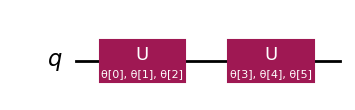

In [32]:
hea_circuit = build_hea(n_sys, 1, hf_circuit)
hea_circuit.draw("mpl")

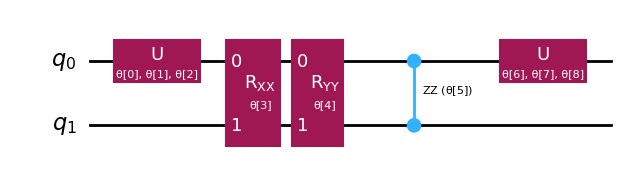

In [33]:
haa_circuit = build_haa(n_sys, 1, 1, hf_circuit)
haa_circuit.draw("mpl")

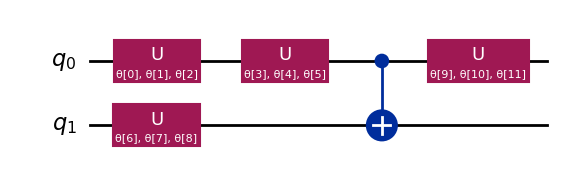

In [34]:
haa_u3cx_circuit = build_haa(n_sys, 1, 1, hf_circuit, "u3cx", "ac")
haa_u3cx_circuit.draw("mpl")

In [35]:
print(expressibility(hea_circuit))
print(expressibility(haa_circuit))
print(expressibility(haa_u3cx_circuit))

0.05225319534593169
0.0698654533814222
0.05209405154444047


In [29]:
print(bp_analysis(hea_circuit, qop, 0))
print(bp_analysis(haa_circuit, qop, 1))
print(bp_analysis(haa_u3cx_circuit, qop, 1))

0.0410594192693997
0.03762685554616584
0.03984377406075851


In [36]:
maxiter = 500
energy_hea = run_vqe(hea_circuit, qop, lambda: ADAM(maxiter=maxiter), 0, enuc=enuc, e_off=e_off)
energy_haa = run_vqe(haa_circuit, qop, lambda: ADAM(maxiter=maxiter), 1, enuc=enuc, e_off=e_off)
energy_haa_u3cx = run_vqe(haa_u3cx_circuit, qop, lambda: ADAM(maxiter=maxiter), 1, enuc=enuc, e_off=e_off)

print(f"HEA energy: {energy_hea:.6f} Ha error {np.abs(energy_hea - E_FCI)} Ha")
print(f"HAA energy: {energy_haa:.6f} Ha error {np.abs(energy_haa - E_FCI)} Ha")
print(f"HAA U3CX energy: {energy_haa_u3cx:.6f} Ha error {np.abs(energy_haa_u3cx - E_FCI)} Ha")

HEA energy: -1.056630 Ha error 0.05273668793547559 Ha
HAA energy: -1.108954 Ha error 0.00041273484165205154 Ha
HAA U3CX energy: -1.037097 Ha error 0.07226987397857187 Ha
